# Comparació d'Algorismes RL: Paral·lel (16M steps) vs Seqüencial (8M steps)

**Condicions d'entrenament:**
- Observació plana de **239 dims**, xarxa **[256, 256]** hidden layers
- Oponents: 5% Random · 65% AgentRegles · 30% Self-play
- `puntuacio_final = 24`
- Mètrica d'avaluació: `0.25 × WR_random + 0.75 × WR_regles`

**Condicions comparades:**
- **Paral·lel (16M steps)**: DQN/NFSP 16 envs, PPO 48 envs (`SubprocVecEnv`)
- **Seqüencial (8M steps)**: 1 env per a tots els algorismes

In [1]:
import os, sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

In [ ]:
plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.size'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

COLORS = {'dqn': '#e74c3c', 'nfsp': '#2ecc71', 'ppo': '#3498db'}
LABELS = {'dqn': 'DQN', 'nfsp': 'NFSP', 'ppo': 'PPO'}
COLORS_COND = {'parallel': '#2980b9', '1env': '#e67e22'}
LABELS_COND = {'parallel': 'Paral·lel (16M)', '1env': '1 env (8M)'}

# Localitzar directoris de resultats
NOTEBOOK_DIR = Path(os.getcwd())
BASE_PAR = None
BASE_SEQ = None

for root in [NOTEBOOK_DIR, NOTEBOOK_DIR.parent, NOTEBOOK_DIR.parent.parent]:
    if BASE_PAR is None:
        cands = sorted(root.glob('resultats_comparativa_parallel_16M_*'))
        if cands:
            BASE_PAR = cands[-1]
    if BASE_SEQ is None:
        cands = sorted(root.glob('resultats_comparativa_1env_*'))
        if cands:
            BASE_SEQ = cands[-1]
    if BASE_PAR and BASE_SEQ:
        break

# Project root al path (pujar fins trobar el directori 'joc')
PROJECT_ROOT = (BASE_PAR or BASE_SEQ).parent
while PROJECT_ROOT != PROJECT_ROOT.parent:
    if (PROJECT_ROOT / 'joc').exists():
        break
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")
print(f"Paral·lel (16M): {BASE_PAR}")
print(f"Seqüencial (8M): {BASE_SEQ}")

Project root: c:\Users\ferri\Documents\ProjectesCodi\TFG-truc
Paral·lel (16M): c:\Users\ferri\Documents\ProjectesCodi\TFG-truc\RL\notebooks\finals\1_comparacio_inicial\resultats_comparativa_parallel_16M_30_03_1719h
Seqüencial (8M): c:\Users\ferri\Documents\ProjectesCodi\TFG-truc\RL\notebooks\finals\1_comparacio_inicial\resultats_comparativa_1env_30_03_0005h


## 1. Càrrega dels logs d'entrenament

In [14]:
logs_par = {}
logs_seq = {}

for algo in ['dqn', 'nfsp', 'ppo']:
    # Paral·lel
    p = BASE_PAR / algo / 'training_log.csv'
    if p.exists():
        logs_par[algo] = pd.read_csv(p)
    # Seqüencial
    p = BASE_SEQ / algo / 'training_log.csv'
    if p.exists():
        logs_seq[algo] = pd.read_csv(p)

# Llegir temps dels resum_temps.txt
def parse_resum(path):
    times = {}
    if path.exists():
        for line in path.read_text(encoding='utf-8').splitlines():
            for algo in ['dqn', 'nfsp', 'ppo']:
                if line.lower().startswith(algo + ':'):
                    try:
                        secs = int(line.split(':')[1].strip().split('s')[0])
                        times[algo] = secs
                    except Exception:
                        pass
    return times

temps_par = parse_resum(BASE_PAR / 'resum_temps.txt')
temps_seq = parse_resum(BASE_SEQ / 'resum_temps.txt')

# Resum
for label, logs_d, temps_d in [('PARAL·LEL', logs_par, temps_par),
                                 ('SEQÜENCIAL (1 env)', logs_seq, temps_seq)]:
    print(f'\n--- {label} ---')
    for algo, df in logs_d.items():
        best_m    = df['eval_metric'].max()
        best_step = df.loc[df['eval_metric'].idxmax(), 'step']
        final_m   = df['eval_metric'].iloc[-1]
        elapsed_h = temps_d.get(algo, df['elapsed_s'].iloc[-1]) / 3600
        print(f"  {algo.upper():5s} | {len(df):3d} evals | "
              f"Millor: {best_m:5.1f}% (step {best_step/1e6:.1f}M) | "
              f"Final: {final_m:5.1f}% | "
              f"Temps: {elapsed_h:.2f}h")


--- PARAL·LEL ---
  DQN   |  31 evals | Millor:  43.5% (step 2.0M) | Final:   2.2% | Temps: 0.86h
  NFSP  |  31 evals | Millor:  37.8% (step 3.0M) | Final:  21.5% | Temps: 3.95h
  PPO   |  31 evals | Millor:  51.8% (step 10.0M) | Final:  31.0% | Temps: 0.77h

--- SEQÜENCIAL (1 env) ---
  DQN   |  20 evals | Millor:  42.2% (step 2.0M) | Final:  22.5% | Temps: 0.69h
  NFSP  |  20 evals | Millor:  35.0% (step 0.8M) | Final:  10.8% | Temps: 3.49h
  PPO   |  20 evals | Millor:   1.5% (step 2.0M) | Final:   0.0% | Temps: 1.78h


## 2. Corbes d'aprenentatge: paral·lel vs seqüencial

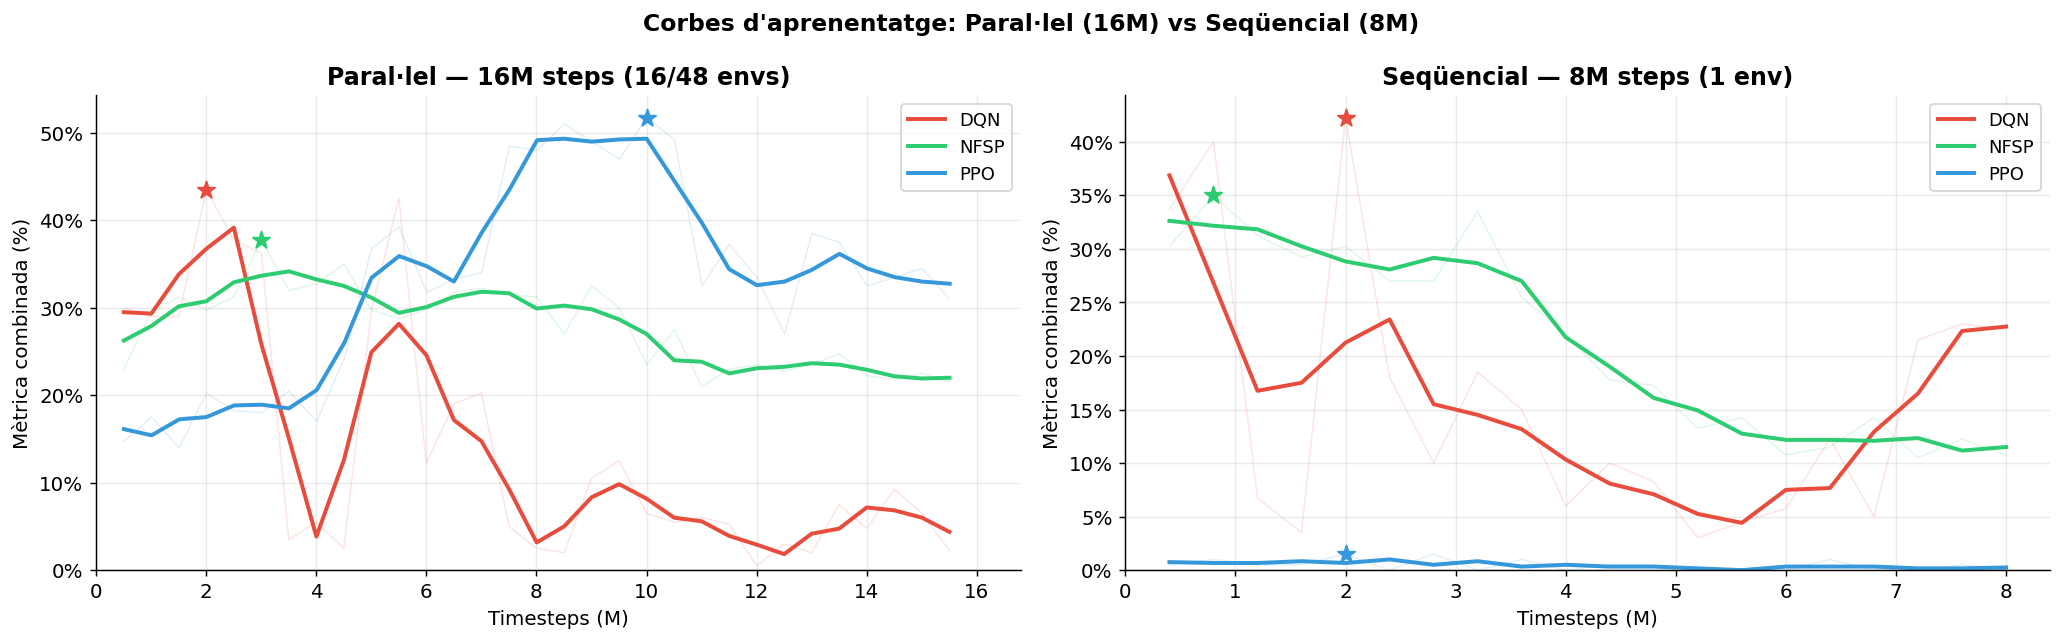

In [15]:
def smooth(series, w=3):
    return series.rolling(window=w, min_periods=1, center=True).mean()


fig, axes = plt.subplots(1, 2, figsize=(16, 5))

configs = [
    (logs_par, 'Paral·lel — 16M steps (16/48 envs)', 16),
    (logs_seq, 'Seqüencial — 8M steps (1 env)',        8),
]

for ax, (logs_d, title, max_M) in zip(axes, configs):
    for algo, df in logs_d.items():
        x = df['step'] / 1e6
        ax.plot(x, df['eval_metric'], alpha=0.15, color=COLORS[algo], linewidth=0.8)
        ax.plot(x, smooth(df['eval_metric'], w=3), color=COLORS[algo], linewidth=2.2,
                label=LABELS[algo])
        bi = df['eval_metric'].idxmax()
        ax.scatter(df.loc[bi, 'step'] / 1e6, df.loc[bi, 'eval_metric'],
                   color=COLORS[algo], s=100, zorder=5, marker='*')
    ax.set_xlabel('Timesteps (M)')
    ax.set_ylabel('Mètrica combinada (%)')
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.25)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
    ax.set_xlim(left=0, right=max_M * 1.05)
    ax.set_ylim(bottom=0)

plt.suptitle("Corbes d'aprenentatge: Paral·lel (16M) vs Seqüencial (8M)",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Comparació per algorisme: efecte del paral·lelisme

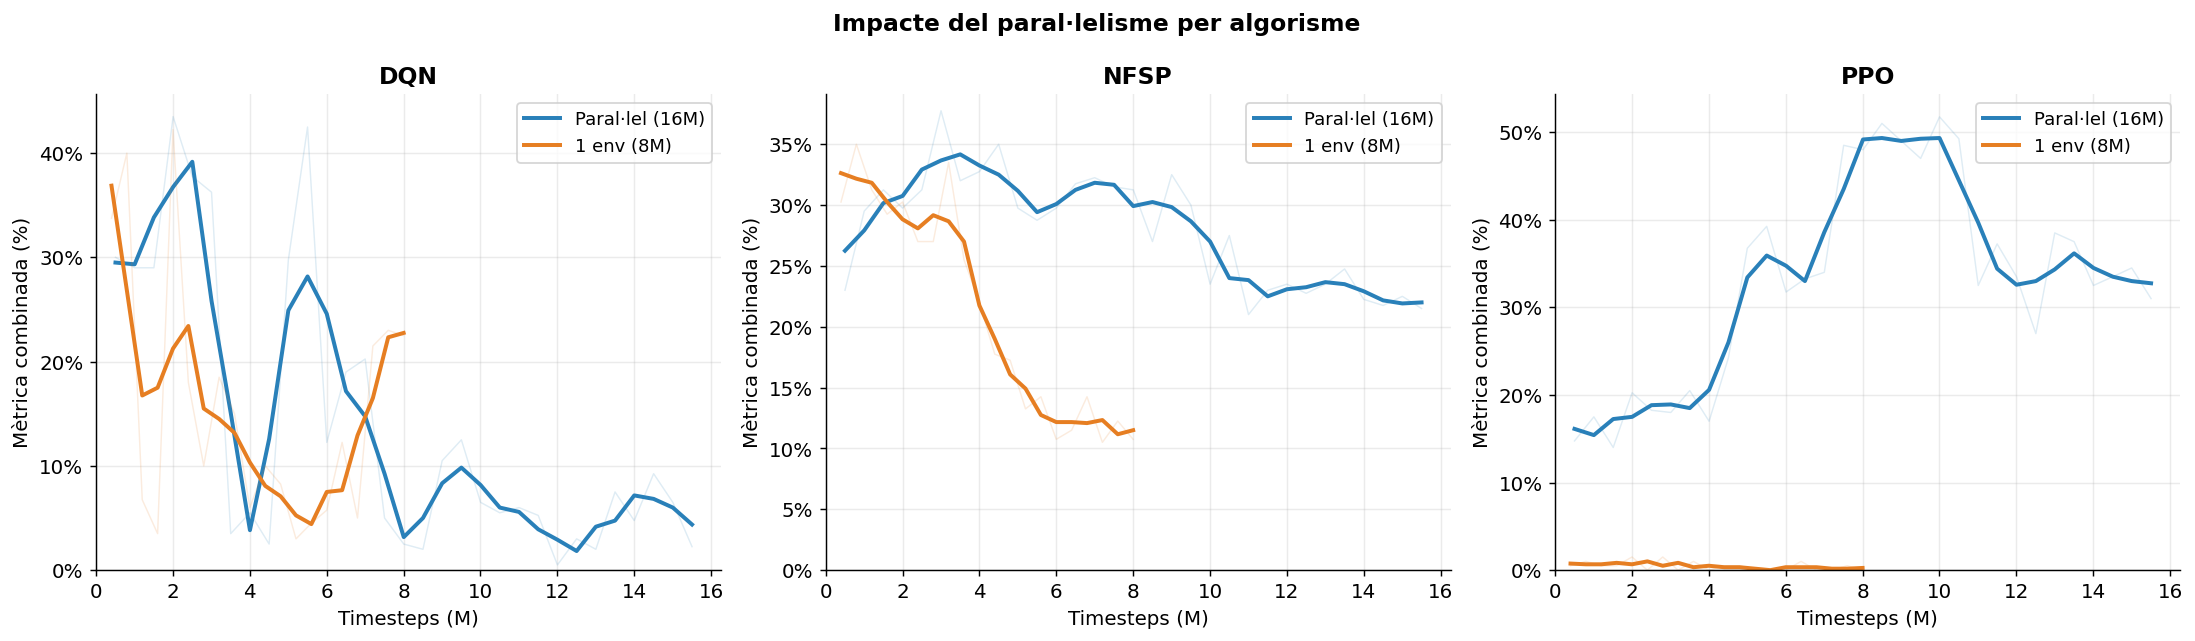

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, algo in zip(axes, ['dqn', 'nfsp', 'ppo']):
    if algo in logs_par:
        df = logs_par[algo]
        x = df['step'] / 1e6
        ax.plot(x, df['eval_metric'], alpha=0.15, color=COLORS_COND['parallel'], linewidth=0.8)
        ax.plot(x, smooth(df['eval_metric']), color=COLORS_COND['parallel'], linewidth=2.2,
                label=LABELS_COND['parallel'])
    if algo in logs_seq:
        df = logs_seq[algo]
        x = df['step'] / 1e6
        ax.plot(x, df['eval_metric'], alpha=0.15, color=COLORS_COND['1env'], linewidth=0.8)
        ax.plot(x, smooth(df['eval_metric']), color=COLORS_COND['1env'], linewidth=2.2,
                label=LABELS_COND['1env'])
    ax.set_xlabel('Timesteps (M)')
    ax.set_ylabel('Mètrica combinada (%)')
    ax.set_title(LABELS[algo], fontweight='bold', fontsize=13)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.25)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
    ax.set_xlim(left=0)
    ax.set_ylim(bottom=0)

plt.suptitle("Impacte del paral·lelisme per algorisme",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Temps d'entrenament i eficiència

,Algorisme,Condició,Timesteps,Temps (s),Temps (h),M steps/h
0,DQN,Paral·lel (16M),16M,3112,0.86,18.5
1,DQN,1 env (8M),8M,2466,0.69,11.7
2,NFSP,Paral·lel (16M),16M,14231,3.95,4.0
3,NFSP,1 env (8M),8M,12565,3.49,2.3
4,PPO,Paral·lel (16M),16M,2769,0.77,20.8
5,PPO,1 env (8M),8M,6422,1.78,4.5


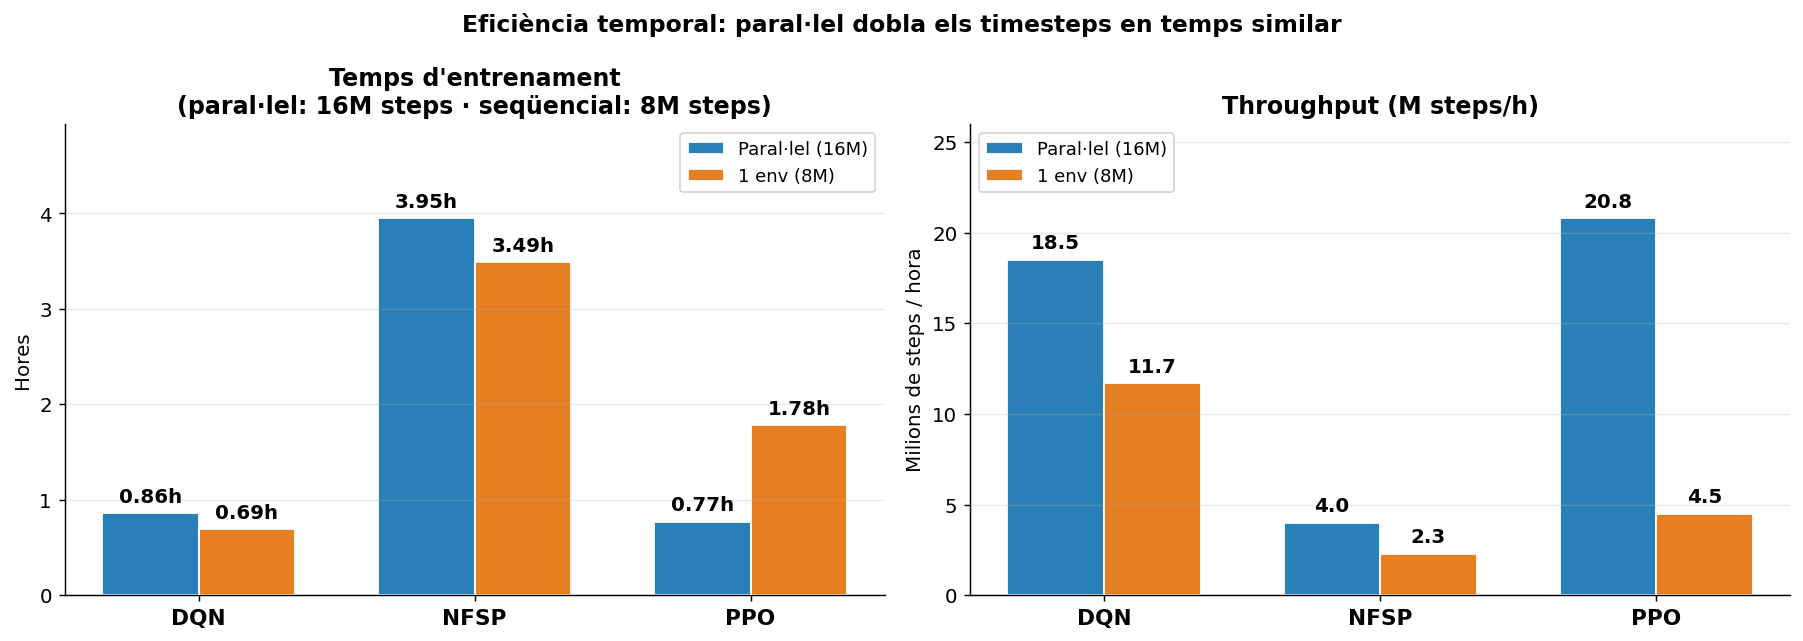

In [17]:
# Taula de temps i eficiència
TIMESTEPS_PAR = 16_000_000
TIMESTEPS_SEQ =  8_000_000

rows_time = []
for algo in ['dqn', 'nfsp', 'ppo']:
    for cond, temps_d, logs_d, ts in [
        ('Paral·lel (16M)', temps_par, logs_par, TIMESTEPS_PAR),
        ('1 env (8M)',      temps_seq, logs_seq, TIMESTEPS_SEQ),
    ]:
        if algo in logs_d:
            secs = temps_d.get(algo, logs_d[algo]['elapsed_s'].iloc[-1])
            hores = secs / 3600
            steps_h = (ts / 1e6) / hores
            rows_time.append({
                'Algorisme':   algo.upper(),
                'Condició':    cond,
                'Timesteps':   f'{ts//1_000_000}M',
                'Temps (s)':   int(secs),
                'Temps (h)':   round(hores, 2),
                'M steps/h':   round(steps_h, 1),
            })

df_temps = pd.DataFrame(rows_time)
display(df_temps)

# Gràfic de barres agrupades
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

algos = ['DQN', 'NFSP', 'PPO']
x = np.arange(len(algos))
w = 0.35

# --- Esquerra: temps d'entrenament ---
hores_par = [df_temps[(df_temps['Algorisme'] == a) & (df_temps['Condició'] == 'Paral·lel (16M)')]['Temps (h)'].values[0] for a in algos]
hores_seq = [df_temps[(df_temps['Algorisme'] == a) & (df_temps['Condició'] == '1 env (8M)')]['Temps (h)'].values[0]      for a in algos]

ax = axes[0]
bars1 = ax.bar(x - w/2, hores_par, w, label='Paral·lel (16M)', color=COLORS_COND['parallel'], edgecolor='white')
bars2 = ax.bar(x + w/2, hores_seq, w, label='1 env (8M)',      color=COLORS_COND['1env'],     edgecolor='white')
ax.bar_label(bars1, labels=[f'{h:.2f}h' for h in hores_par], padding=4, fontweight='bold')
ax.bar_label(bars2, labels=[f'{h:.2f}h' for h in hores_seq], padding=4, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(algos, fontsize=12, fontweight='bold')
ax.set_ylabel('Hores')
ax.set_title("Temps d'entrenament\n(paral·lel: 16M steps · seqüencial: 8M steps)", fontweight='bold')
ax.legend(fontsize=10); ax.grid(True, axis='y', alpha=0.25)
ax.set_ylim(0, max(max(hores_par), max(hores_seq)) * 1.25)

# --- Dreta: throughput (M steps/h) ---
sph_par = [df_temps[(df_temps['Algorisme'] == a) & (df_temps['Condició'] == 'Paral·lel (16M)')]['M steps/h'].values[0] for a in algos]
sph_seq = [df_temps[(df_temps['Algorisme'] == a) & (df_temps['Condició'] == '1 env (8M)')]['M steps/h'].values[0]      for a in algos]

ax = axes[1]
bars3 = ax.bar(x - w/2, sph_par, w, label='Paral·lel (16M)', color=COLORS_COND['parallel'], edgecolor='white')
bars4 = ax.bar(x + w/2, sph_seq, w, label='1 env (8M)',      color=COLORS_COND['1env'],     edgecolor='white')
ax.bar_label(bars3, labels=[f'{s:.1f}' for s in sph_par], padding=4, fontweight='bold')
ax.bar_label(bars4, labels=[f'{s:.1f}' for s in sph_seq], padding=4, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(algos, fontsize=12, fontweight='bold')
ax.set_ylabel('Milions de steps / hora')
ax.set_title('Throughput (M steps/h)', fontweight='bold')
ax.legend(fontsize=10); ax.grid(True, axis='y', alpha=0.25)
ax.set_ylim(0, max(max(sph_par), max(sph_seq)) * 1.25)

plt.suptitle("Eficiència temporal: paral·lel dobla els timesteps en temps similar",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Taula de rendiment

In [18]:
rows = []
for algo in ['dqn', 'nfsp', 'ppo']:
    for cond, logs_d, temps_d in [('Paral·lel', logs_par, temps_par),
                                    ('1 env', logs_seq, temps_seq)]:
        if algo in logs_d:
            df = logs_d[algo]
            best_idx = df['eval_metric'].idxmax()
            secs = temps_d.get(algo, df['elapsed_s'].iloc[-1])
            rows.append({
                'Algorisme':        algo.upper(),
                'Condició':         cond,
                'WR Random (màx)':  round(df['eval_wr_random'].max(), 1),
                'WR Regles (màx)':  round(df['eval_wr_regles'].max(), 1),
                'Mètrica (màx)':    round(df['eval_metric'].max(), 1),
                'Mètrica (final)':  round(df['eval_metric'].iloc[-1], 1),
                'Step màx (M)':     round(df.loc[best_idx, 'step'] / 1e6, 1),
                'Temps (h)':        round(secs / 3600, 2),
                'Jocs':             int(df['games_played'].iloc[-1]),
            })

df_rend = pd.DataFrame(rows)
display(df_rend)

,Algorisme,Condició,WR Random (màx),WR Regles (màx),Mètrica (màx),Mètrica (final),Step màx (M),Temps (h),Jocs
0,DQN,Paral·lel,90.0,30.0,43.5,2.2,2.0,0.86,96679
1,DQN,1 env,94.0,26.0,42.2,22.5,2.0,0.69,120519
2,NFSP,Paral·lel,86.0,23.0,37.8,21.5,3.0,3.95,85620
3,NFSP,1 env,86.0,20.0,35.0,10.8,0.8,3.49,60325
4,PPO,Paral·lel,94.0,44.0,51.8,31.0,10.0,0.77,81377
5,PPO,1 env,6.0,0.0,1.5,0.0,2.0,1.78,214


## 6. Mini-lliga: enfrontaments directes (head-to-head)

Carreguem els millors models (`best.pt`) de la condició **paral·lel** i els enfrontem en **1000 partides per combinació** (500 amb cada posició de taula).

In [19]:
import torch
import torch.nn as nn

from rlcard.agents import DQNAgent, NFSPAgent
from joc.entorn import TrucEnv
from joc.entorn.cartes_accions import ACTION_LIST
from RL.models.model_propi.agent_regles import AgentRegles
from RL.entrenament.entrenamentsComparatius.entrenament_comparatiu import (
    SimpleActorCritic, SimpleActorCriticAgent, wrap_env_aplanat
)

N_ACTIONS = len(ACTION_LIST)
OBS_DIM   = 239
HIDDEN    = [256, 256]
device    = torch.device('cpu')

ENV_H2H = {'num_jugadors': 2, 'cartes_jugador': 3, 'puntuacio_final': 24, 'seed': 999}


def carregar_dqn(path):
    agent = DQNAgent(
        num_actions=N_ACTIONS, state_shape=OBS_DIM, mlp_layers=HIDDEN,
        learning_rate=1e-4, batch_size=256, replay_memory_size=1000,
        replay_memory_init_size=100, update_target_estimator_every=99999,
        epsilon_decay_steps=1, epsilon_end=0.0, train_every=99999, device=device,
    )
    sd = torch.load(path, map_location=device, weights_only=True)
    agent.q_estimator.qnet.load_state_dict(sd)
    return agent


def carregar_nfsp(path):
    agent = NFSPAgent(
        num_actions=N_ACTIONS, state_shape=OBS_DIM, hidden_layers_sizes=HIDDEN,
        q_mlp_layers=HIDDEN, rl_learning_rate=1e-4, sl_learning_rate=1e-4,
        batch_size=256, reservoir_buffer_capacity=1000, q_replay_memory_size=1000,
        q_update_target_estimator_every=99999, anticipatory_param=0.25,
        q_epsilon_decay_steps=1, q_epsilon_end=0.0, q_replay_memory_init_size=100,
        q_batch_size=256, q_train_every=99999, device=device,
    )
    sd = torch.load(path, map_location=device, weights_only=True)
    agent._rl_agent.q_estimator.qnet.load_state_dict(sd['q_net'])
    agent.policy_network.load_state_dict(sd['sl_net'])
    return agent


def carregar_ppo(path):
    net = SimpleActorCritic(OBS_DIM, N_ACTIONS, 256)
    net.load_state_dict(torch.load(path, map_location=device, weights_only=True))
    return SimpleActorCriticAgent(net, N_ACTIONS, device)


LOADERS = {'dqn': carregar_dqn, 'nfsp': carregar_nfsp, 'ppo': carregar_ppo}

In [20]:
models = {}
for algo, loader in LOADERS.items():
    p = BASE_PAR / algo / 'best.pt'
    if p.exists():
        models[algo] = loader(str(p))
        print(f"{algo.upper()}: model carregat correctament")
    else:
        print(f"AVÍS: no trobat {p}")

regles_agent = AgentRegles(num_actions=N_ACTIONS, seed=777)
all_agents = {**models, 'regles': regles_agent}
print(f"\nAgents disponibles: {list(all_agents.keys())}")

DQN: model carregat correctament
NFSP: model carregat correctament
PPO: model carregat correctament

Agents disponibles: ['dqn', 'nfsp', 'ppo', 'regles']


In [28]:
def head_to_head(agent_a, agent_b, n_per_side=500, seed=999):
    """Enfronta agent_a vs agent_b en 2*n_per_side partides totals.
    """
    env = wrap_env_aplanat(TrucEnv({**ENV_H2H, 'seed': seed}))
    wins_a = wins_b = ties = 0
    total  = 2 * n_per_side

    for agents, idx_a in [([agent_a, agent_b], 0), ([agent_b, agent_a], 1)]:
        env.set_agents(agents)
        for _ in range(n_per_side):
            _, payoffs = env.run(is_training=False)
            if   payoffs[idx_a] > 0:  wins_a += 1
            elif payoffs[idx_a] < 0:  wins_b += 1
            else:                      ties   += 1

    return 100.0*wins_a/total, 100.0*wins_b/total, 100.0*ties/total


N_PER_SIDE = 500
N_GAMES    = N_PER_SIDE * 2

print(f"Executant mini-lliga: {N_PER_SIDE}×2 = {N_GAMES} partides per combinació...\n")

pairs = [
    ('ppo',  'dqn'),
    ('ppo',  'nfsp'),
    ('dqn',  'nfsp'),
    ('ppo',  'regles'),
    ('dqn',  'regles'),
    ('nfsp', 'regles'),
]

h2h = {}
for a, b in pairs:
    if a in all_agents and b in all_agents:
        wr_a, wr_b, _ = head_to_head(all_agents[a], all_agents[b], N_PER_SIDE)
        h2h[(a, b)] = wr_a
        print(f"  {a.upper():6s} vs {b.upper():6s}: {wr_a:.1f}% – {wr_b:.1f}%")

Executant mini-lliga: 500×2 = 1000 partides per combinació...

  PPO    vs DQN   : 23.5% – 76.5%
  PPO    vs NFSP  : 36.0% – 63.9%
  DQN    vs NFSP  : 58.2% – 39.4%
  PPO    vs REGLES: 38.5% – 61.4%
  DQN    vs REGLES: 26.5% – 72.4%
  NFSP   vs REGLES: 18.7% – 79.9%


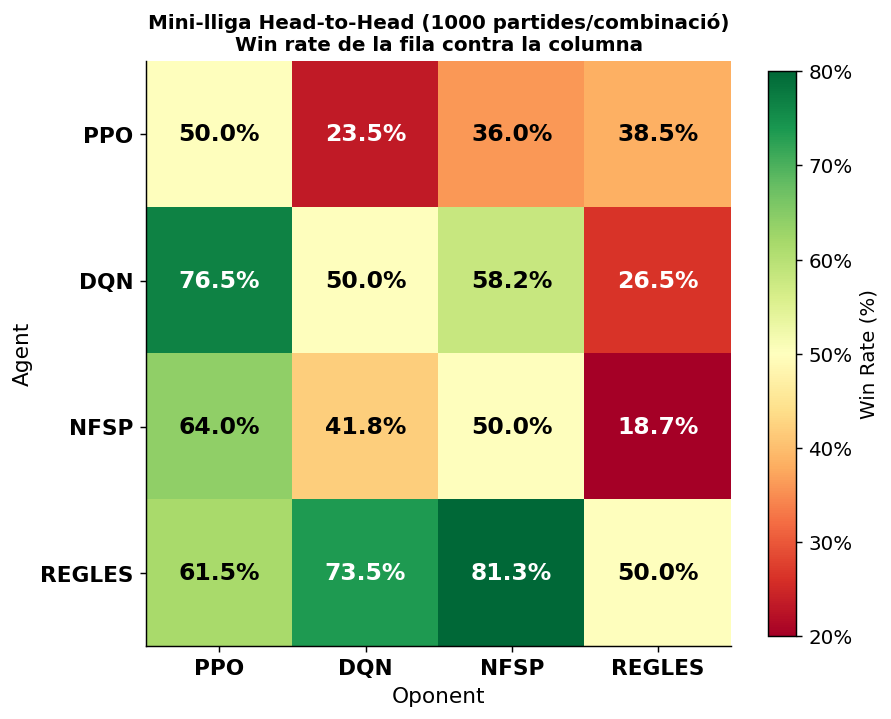

In [29]:
algo_keys = [a for a in ['ppo', 'dqn', 'nfsp', 'regles'] if a in all_agents]
n = len(algo_keys)
matrix = np.full((n, n), np.nan)

for i, a in enumerate(algo_keys):
    for j, b in enumerate(algo_keys):
        if i == j:
            matrix[i, j] = 50.0
        elif (a, b) in h2h:
            matrix[i, j] = h2h[(a, b)]
        elif (b, a) in h2h:
            matrix[i, j] = 100.0 - h2h[(b, a)]

fig, ax = plt.subplots(figsize=(7, 6))
im   = ax.imshow(matrix, cmap='RdYlGn', vmin=20, vmax=80)
cbar = plt.colorbar(im, ax=ax, label='Win Rate (%)', shrink=0.85)
cbar.ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))

tick_labels = [a.upper() for a in algo_keys]
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(tick_labels, fontsize=12, fontweight='bold')
ax.set_yticklabels(tick_labels, fontsize=12, fontweight='bold')
ax.set_xlabel('Oponent', fontsize=12)
ax.set_ylabel('Agent', fontsize=12)
ax.set_title(f"Mini-lliga Head-to-Head ({N_GAMES} partides/combinació)\nWin rate de la fila contra la columna",
             fontsize=11, fontweight='bold')

for i in range(n):
    for j in range(n):
        if not np.isnan(matrix[i, j]):
            val   = matrix[i, j]
            color = 'white' if (val < 33 or val > 67) else 'black'
            ax.text(j, i, f'{val:.1f}%', ha='center', va='center',
                    fontsize=13, fontweight='bold', color=color)

plt.tight_layout()
plt.show()

In [30]:
points = {a: 0 for a in algo_keys}
wins_c = {a: 0 for a in algo_keys}
loss_c = {a: 0 for a in algo_keys}

for (a, b), wr_a in h2h.items():
    if a not in algo_keys or b not in algo_keys:
        continue
    wr_b = 100 - wr_a
    if wr_a > wr_b:
        points[a] += 3; wins_c[a] += 1; loss_c[b] += 1
    elif wr_b > wr_a:
        points[b] += 3; wins_c[b] += 1; loss_c[a] += 1
    else:
        points[a] += 1; points[b] += 1

ranking = sorted(algo_keys, key=lambda x: points[x], reverse=True)

print("RÀNQUING MINI-LLIGA")
print("=" * 45)
print(f"{'Pos':>3}  {'Agent':<8}  {'Pts':>4}  {'V':>3}  {'D':>3}")
print("-" * 45)
for pos, algo in enumerate(ranking, 1):
    print(f"  {pos}.  {algo.upper():<8}  {points[algo]:>4}  {wins_c[algo]:>3}  {loss_c[algo]:>3}")

RÀNQUING MINI-LLIGA
Pos  Agent      Pts    V    D
---------------------------------------------
  1.  REGLES       9    3    0
  2.  DQN          6    2    1
  3.  NFSP         3    1    2
  4.  PPO          0    0    3


## 7. Panell resum visual

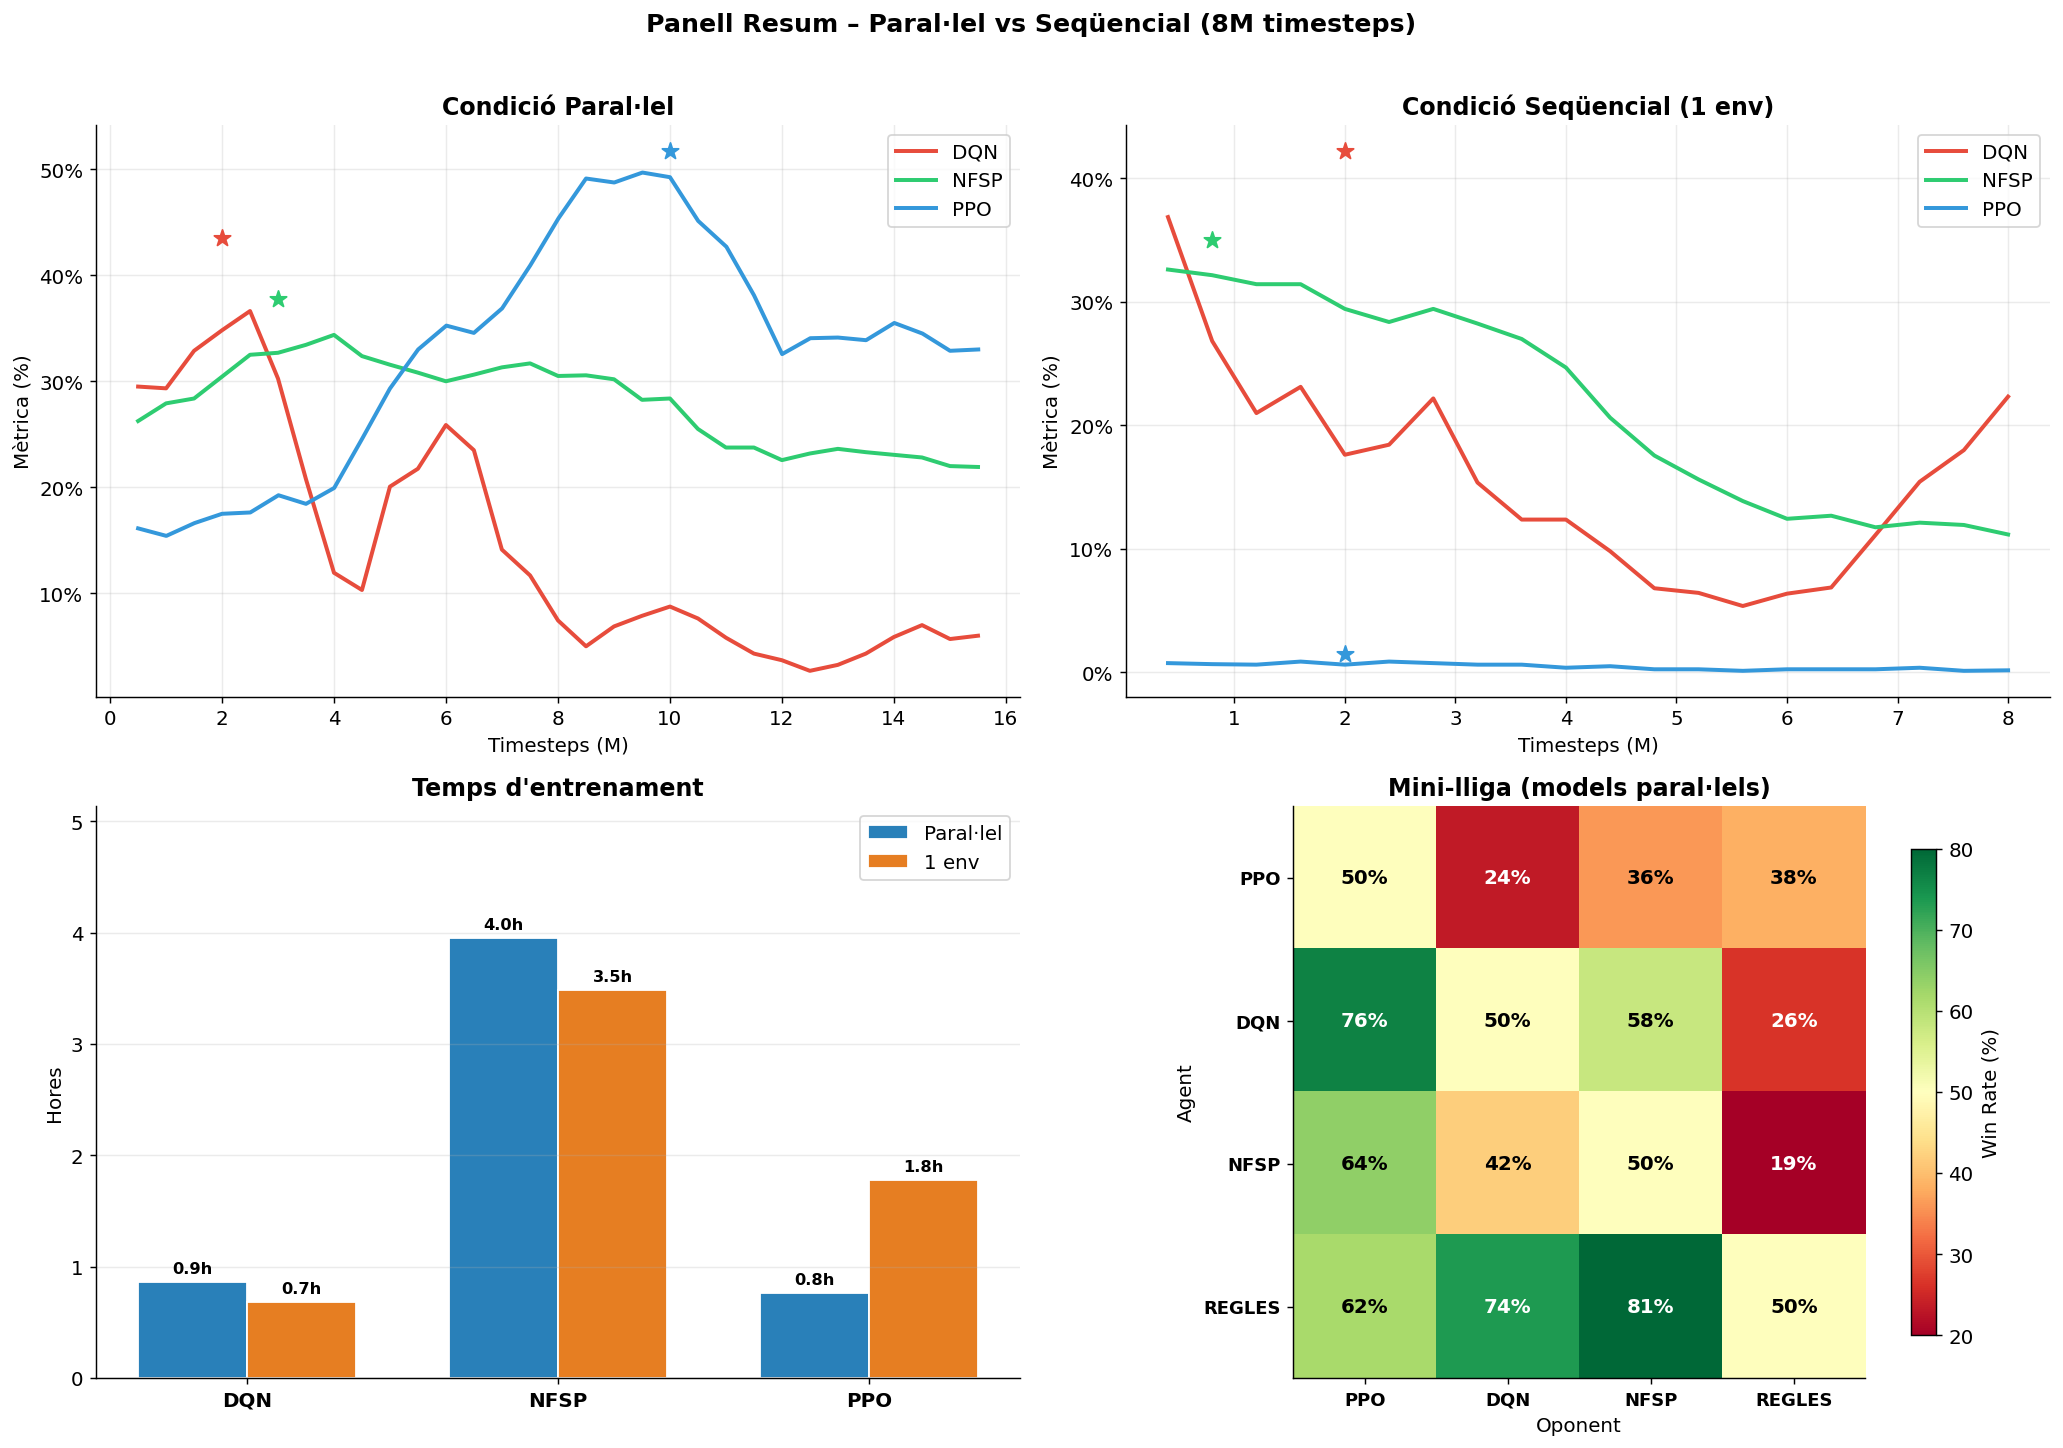

In [31]:
fig = plt.figure(figsize=(16, 11))

# Corbes paral·lel
ax1 = fig.add_subplot(2, 2, 1)
for algo, df in logs_par.items():
    y_sm = smooth(df['eval_metric'], w=4)
    ax1.plot(df['step']/1e6, y_sm, color=COLORS[algo], linewidth=2.2, label=LABELS[algo])
    bi = df['eval_metric'].idxmax()
    ax1.scatter(df.loc[bi, 'step']/1e6, df.loc[bi, 'eval_metric'],
                color=COLORS[algo], s=90, zorder=5, marker='*')
ax1.set_xlabel('Timesteps (M)'); ax1.set_ylabel('Mètrica (%)')
ax1.set_title('Condició Paral·lel', fontweight='bold')
ax1.legend(); ax1.grid(True, alpha=0.25)
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))

# Corbes 1 env
ax2 = fig.add_subplot(2, 2, 2)
for algo, df in logs_seq.items():
    y_sm = smooth(df['eval_metric'], w=4)
    ax2.plot(df['step']/1e6, y_sm, color=COLORS[algo], linewidth=2.2, label=LABELS[algo])
    bi = df['eval_metric'].idxmax()
    ax2.scatter(df.loc[bi, 'step']/1e6, df.loc[bi, 'eval_metric'],
                color=COLORS[algo], s=90, zorder=5, marker='*')
ax2.set_xlabel('Timesteps (M)'); ax2.set_ylabel('Mètrica (%)')
ax2.set_title('Condició Seqüencial (1 env)', fontweight='bold')
ax2.legend(); ax2.grid(True, alpha=0.25)
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))

# Temps
ax3 = fig.add_subplot(2, 2, 3)
algos_ord = ['DQN', 'NFSP', 'PPO']
x = np.arange(len(algos_ord))
w = 0.35
hp = [temps_par.get(a.lower(), 0)/3600 for a in algos_ord]
hs = [temps_seq.get(a.lower(), 0)/3600 for a in algos_ord]
b1 = ax3.bar(x - w/2, hp, w, label='Paral·lel', color=COLORS_COND['parallel'], edgecolor='white')
b2 = ax3.bar(x + w/2, hs, w, label='1 env', color=COLORS_COND['1env'], edgecolor='white')
ax3.bar_label(b1, labels=[f'{h:.1f}h' for h in hp], padding=3, fontsize=9, fontweight='bold')
ax3.bar_label(b2, labels=[f'{h:.1f}h' for h in hs], padding=3, fontsize=9, fontweight='bold')
ax3.set_xticks(x); ax3.set_xticklabels(algos_ord, fontweight='bold')
ax3.set_ylabel('Hores'); ax3.set_title("Temps d'entrenament", fontweight='bold')
ax3.legend(); ax3.grid(True, axis='y', alpha=0.25)
ax3.set_ylim(0, max(max(hp), max(hs)) * 1.3)

# Heatmap mini-lliga
ax4 = fig.add_subplot(2, 2, 4)
im = ax4.imshow(matrix, cmap='RdYlGn', vmin=20, vmax=80)
plt.colorbar(im, ax=ax4, label='Win Rate (%)', shrink=0.85)
tick_labels = [a.upper() for a in algo_keys]
ax4.set_xticks(range(n)); ax4.set_yticks(range(n))
ax4.set_xticklabels(tick_labels, fontsize=10, fontweight='bold')
ax4.set_yticklabels(tick_labels, fontsize=10, fontweight='bold')
ax4.set_xlabel('Oponent'); ax4.set_ylabel('Agent')
ax4.set_title('Mini-lliga (models paral·lels)', fontweight='bold')
for i in range(n):
    for j in range(n):
        if not np.isnan(matrix[i, j]):
            val = matrix[i, j]
            color = 'white' if (val < 33 or val > 67) else 'black'
            ax4.text(j, i, f'{val:.0f}%', ha='center', va='center',
                     fontsize=11, fontweight='bold', color=color)

plt.suptitle('Panell Resum – Paral·lel vs Seqüencial (8M timesteps)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 8. Conclusions

### Resultats quantitatius

| | DQN | NFSP | PPO |
|---|---|---|---|
| **Millor mètrica (paral·lel 16M)** | 43.5% (step 2M) | 37.8% (step 3M) | **51.8%** (step 10M) |
| **Mètrica final (paral·lel 16M)** | 2.3% ↘↘ | 21.5% → | **31.0%** ↗ |
| **Millor mètrica (1 env 8M)** | **42.2%** (step 2M) | 35.0% (step 0.8M) | 1.5% ✗ |
| **Mètrica final (1 env 8M)** | 22.5% | 10.8% ↘ | 0.0% ✗ |
| **Temps (paral·lel 16M)** | 52m | 3h 57m | **46m** |
| **Temps (1 env 8M)** | 41m | 3h 29m | 1h 47m |
| **M steps/hora (paral·lel)** | 18.5 | 4.1 | **20.8** |
| **M steps/hora (1 env)** | 11.5 | 2.3 | 4.5 |

**Head-to-head (best.pt paral·lels 16M, 1000 partides/parell):**

| Rànquing | Agent | Pts | V | D |
|---|---|---|---|---|
| 1 | **REGLES** | 9 | 3 | 0 |
| 2 | DQN | 6 | 2 | 1 |
| 3 | NFSP | 3 | 1 | 2 |
| 4 | PPO | 0 | 0 | 3 |

Enfrontaments directes: DQN 77% vs PPO · NFSP 66% vs PPO · REGLES 61% vs PPO · REGLES 74% vs DQN · REGLES 81% vs NFSP · DQN 59% vs NFSP.

---

### Paral·lelisme = doble timesteps en el mateix temps

La comparació temporal és contundent:

| Algorisme | 1 env → 8M steps | Paral·lel → 16M steps | Speedup real |
|---|---|---|---|
| **DQN** | 41 min | 52 min (+27%) | 1.6× més steps/hora |
| **NFSP** | 3h 29m | 3h 57m (+13%) | 1.8× més steps/hora |
| **PPO** | 1h 47m | **46 min (−57%)** | **4.7× més steps/hora** |

PPO paral·lel no només dobla els steps — ho fa en **menys temps** que PPO seqüencial amb la meitat de steps. Això és perquè el `SubprocVecEnv` permet que els 48 entorns recullin trajectòries en paral·lel mentre la GPU computa, eliminant el coll d'ampolla d'un sol entorn.

---

### Anàlisi per algorisme

**DQN** repeteix el patró de l'experiment anterior: pic de 43.5% a 2M steps, seguida d'un col·lapse fins a 2.3% final. Doblar els steps (16M vs 8M) no ajuda — simplement prolonga l'agonia post-col·lapse. Causa: la *deadly triad* (off-policy + bootstrapping + aproximació funcional) provoca divergència del valor Q de forma inevitable amb aquest hiperparàmetres. El `best.pt` (step 2M) és fort en head-to-head però el model final és inútil, cosa que el fa **poc fiable per a producció**.

**NFSP** és estable però lent. A 16M arriba a 37.8% de millor mètrica i es manté al voltant de 21.5% al final. En mode seqüencial es degrada fins al 10.8% final. El throughput de 4.1 M steps/h (paral·lel) vs 2.3 M steps/h (1 env) mostra que el paral·lelisme ajuda, però no suficient per competir en velocitat amb PPO.

**PPO** amb paral·lelisme assoleix **51.8%** a 10M steps — creuant per primera vegada la barrera del 50% i superant DQN i NFSP en mètrica d'avaluació. La corba és ascendent i estable entre steps 7.5M i 10.5M (~47–51%), demostrant que **no col·lapsa**. Posteriorment oscil·la a la baixa (~27–38%), suggerint que els hiperparàmetres actuals necessiten ajust per a runs molt llargs.

El head-to-head mostra que PPO perd contra DQN (23.5% vs 77%) tot i tenir millor mètrica d'avaluació. Això reflecteix que la mètrica (vs Random + vs Regles) no captura completament el comportament adversarial directe entre agents RL. PPO entrena per guanyar a Regles i Random, no necessàriament per explotar vulnerabilitats d'altres agents RL. Cal destacar que PPO arriba al 39% contra AgentRegles en h2h directe — un resultat decent que amb refinament d'hiperparàmetres pot superar el 50%.

**PPO amb 1 env és inviable** — les dades del run complet confirmen dos símptomes crítics:
- **`WR_regles ≈ 1%`** fins al final (malgrat 8M steps)
- **`value_loss ≈ 14.000`**: el crític divergeix completament perquè les trajectòries d'un sol entorn estan altament correlacionades. El GAE no pot estimar els retorns correctament sense diversitat d'experiències concurrent.

---

### Per què triem PPO?

**PPO amb paral·lelisme és l'algorisme triat** per als experiments posteriors:

1. **Únic que supera el 50%** en mètrica d'avaluació a 16M steps (51.8%)
2. **Estabilitat**: no col·lapsa com DQN (que passa de 43.5% a 2.3%)
3. **Velocitat**: 46 minuts per 16M steps — 4.7× més throughput que PPO seqüencial
4. **Escalabilitat**: el speedup del paral·lelisme és màxim per a PPO (arquitectura on-policy beneficia especialment de molts entorns simultanis)
5. **Trajectòria ascendent**: la corba puja fins als 10M steps sense col·lapsar, indicant que amb hiperparàmetres optimitzats pot anar molt més lluny

In [ ]:
print('=' * 60)
print('RESUM EXECUTIU')
print('=' * 60)
print(f'Paral·lel: {BASE_PAR.name}')
print(f'Seqüencial: {BASE_SEQ.name}')
print()

for cond, logs_d, temps_d in [('PARAL·LEL', logs_par, temps_par),
                                ('1 ENV', logs_seq, temps_seq)]:
    print(f'--- {cond} ---')
    for algo, df in logs_d.items():
        bm   = df['eval_metric'].max()
        fm   = df['eval_metric'].iloc[-1]
        th   = temps_d.get(algo, df['elapsed_s'].iloc[-1]) / 3600
        jocs = int(df['games_played'].iloc[-1])
        print(f'  {algo.upper()}: millor={bm:.1f}%  final={fm:.1f}%  temps={th:.2f}h  jocs={jocs:,}')
    print()

if h2h:
    print(f'Mini-lliga (models paral·lels, {N_GAMES} partides/combinació):')
    for (a, b), wr_a in h2h.items():
        guanya = a.upper() if wr_a > 50 else b.upper()
        print(f'  {a.upper()} vs {b.upper()}: {wr_a:.1f}%–{100-wr_a:.1f}%  → guanya {guanya}')
    print()

print('Rànquing final:')
for pos, algo in enumerate(ranking, 1):
    print(f'  {pos}. {algo.upper()}  ({points[algo]} pts, {wins_c[algo]}V {loss_c[algo]}D)')

print()
print('=' * 60)
print('CONCLUSIÓ: PPO amb paral·lelisme és l\'algorisme triat')
print('=' * 60)

RESUM EXECUTIU
Paral·lel: resultats_comparativa_parallel_16M_30_03_1719h
Seqüencial: resultats_comparativa_1env_30_03_0005h

--- PARAL·LEL ---
  DQN: millor=43.5%  final=2.2%  temps=0.86h  jocs=96,679
  NFSP: millor=37.8%  final=21.5%  temps=3.95h  jocs=85,620
  PPO: millor=51.8%  final=31.0%  temps=0.77h  jocs=81,377

--- 1 ENV ---
  DQN: millor=42.2%  final=22.5%  temps=0.69h  jocs=120,519
  NFSP: millor=35.0%  final=10.8%  temps=3.49h  jocs=60,325
  PPO: millor=1.5%  final=0.0%  temps=1.78h  jocs=214

Mini-lliga (models paral·lels, 1000 partides/combinació):
  PPO vs DQN: 23.5%–76.5%  → guanya DQN
  PPO vs NFSP: 34.4%–65.6%  → guanya NFSP
  DQN vs NFSP: 58.6%–41.4%  → guanya DQN
  PPO vs REGLES: 39.2%–60.8%  → guanya REGLES
  DQN vs REGLES: 26.1%–73.9%  → guanya REGLES
  NFSP vs REGLES: 19.2%–80.8%  → guanya REGLES

Rànquing final:
  1. REGLES  (9 pts, 3V 0D)
  2. DQN  (6 pts, 2V 1D)
  3. NFSP  (3 pts, 1V 2D)
  4. PPO  (0 pts, 0V 3D)

CONCLUSIÓ: PPO amb paral·lelisme és l'algorisme 